## Below is the code to recreate Figure 10.

Topic: Showing the brown dwarf companion count distribution to prove an enforced limit of one.

In [1]:
# Importing necessary packages.
import numpy as np
import matplotlib.pyplot as plt
from spisea.imf import multiplicity
from matplotlib import ticker

In [2]:
# synthetic mass distribution (log-uniform)
N = 20000
masses = 10**np.random.uniform(np.log10(0.01), np.log10(10), N)
mult = multiplicity.MultiplicityResolvedDK()

In [3]:
# binarity (BD primaries have ≤ 1 companion)
mf = np.array([mult.multiplicity_fraction(m) for m in masses])
csf = np.array([mult.companion_star_fraction(m) for m in masses])

rand = np.random.rand(len(masses))
is_mult = rand < mf

n_comp = np.zeros(len(masses), dtype=int)

# same process as in MultiplicityUnresolved
for i, m in enumerate(masses):
    if not is_mult[i]:
        n_comp[i] = 0
    elif m <= 0.08:
        n_comp[i] = 1   # hard BD limit
    else:
        n_comp[i] = mult.random_companion_count(1, csf[i], mf[i])

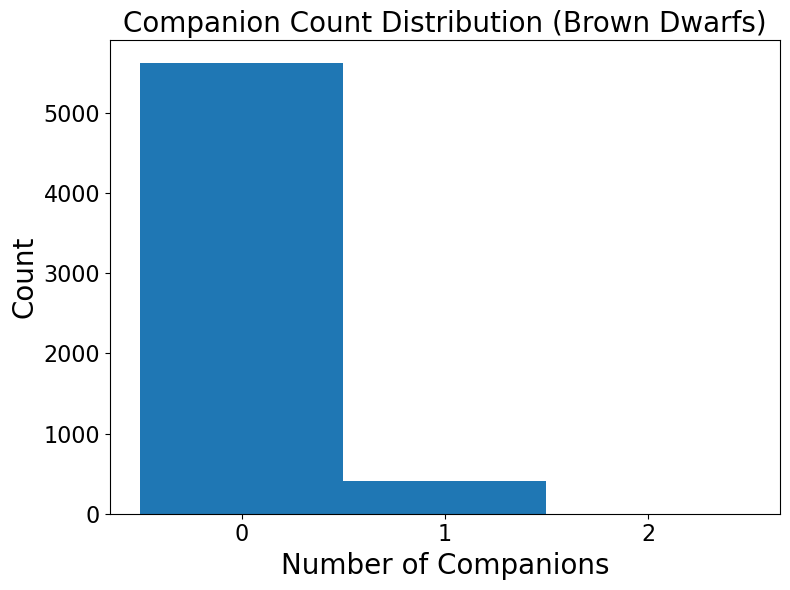

In [4]:
plt.figure(figsize=(8,6))
plt.hist(n_comp[masses <= 0.08], bins=np.linspace(-0.5, 2.5, 4))
plt.xlabel('Number of Companions', fontsize=20)
plt.ylabel('Count', fontsize=20)

ax = plt.gca()  # get current axes
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.title('Companion Count Distribution (Brown Dwarfs)', fontsize=20)
plt.tight_layout()
#plt.savefig('bdbinarity.png')
plt.show()